In [2]:
#import libarries
import pandas as pd
import numpy as np
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from enum import CONTINUOUS
import ipywidgets as widgets
from IPython.display import display


# Data download and undertsandoing

In [5]:
data=pd.read_csv('/content/sample_data/movies.csv')

In [ ]:
#data imformations culomns and types and numbers of rows
data.info()

In [7]:
ratings =pd.read_csv('/content/sample_data/ratings.csv')

In [ ]:
ratings.inf()

we have tow datasets one for movies the other for ratings .

# Preprocesing the data

In [8]:
#fucion to covert the title to be attractive title and more acceptable
def clean_title(title):
  title=re.sub("[^a-zA-Z0-9 ]","",title)
  return title


In [25]:
#apply the function up clean_title for all movies title
data['attractive title']=data['title'].apply(clean_title)


In [24]:
#build tfidf vector-transform the data
tfdf=TfidfVectorizer()
transform_data=tfdf.fit_transform(data['attractive title'])

In [14]:
#building an coollaborative   search function  for movies

def search(title):
  title=clean_title(title)
  qury_vec=tfdf.transform([title])
  similarity=cosine_similarity(qury_vec,transform_data).flatten()
  indecies=np.argpartition(similarity,-5)[-5:]
  results=data.iloc[indecies][: :-1]
  return results

In [ ]:
sch=search('harry potter')
print(sch)

Building wedget for recomendation  movies depending on its title  
# 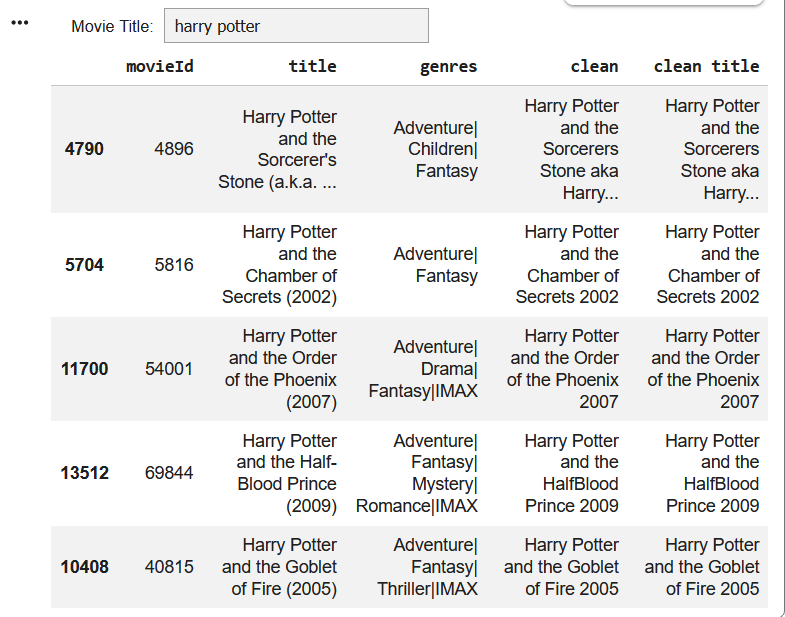

In [ ]:
movie_input_name=widgets.Text(
    value='Toy Story',
    description='Movie Title:',
    disabled=False,

)
recomendation_movie_list=widgets.Output()

def on_type(data):
  with recomendation_movie_list:
    recomendation_movie_list.clear_output()
    title=data["new"]
    if len(title)>5:
      results=search(title)
      if not results.empty:
                try:
                    display(results)
                except Exception as e:
                    print(f"Error finding recommendations: {e}")
      else:
                print("No movies found matching that title.")

movie_input_name.observe(on_type,names='value')
display(movie_input_name,recomendation_movie_list)

recomendation system
---
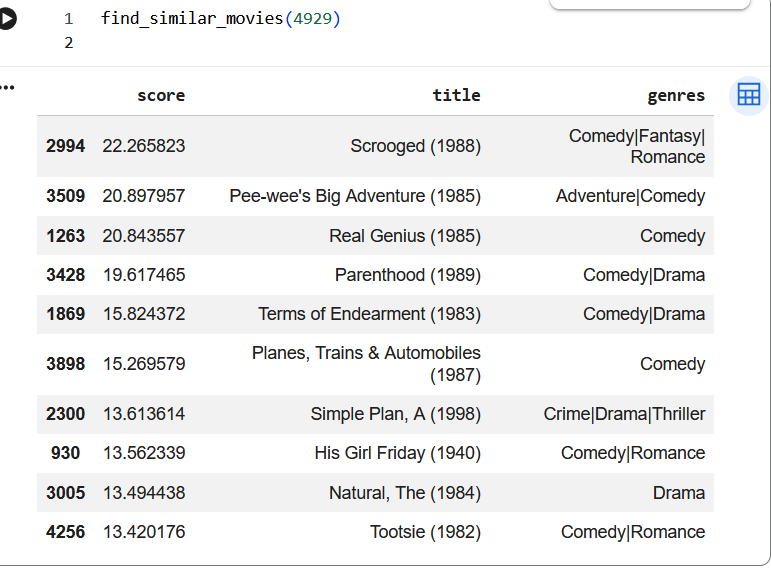

In [19]:
#build rocemndation function
def find_similar_movies(movie_id):
  # Find users who rated the given movie_id poorly
  similar_users = ratings[(ratings['movieId'] == movie_id) & (ratings['rating'] < 4)]['userId']

  if similar_users.empty:
    return pd.DataFrame(columns=['score', 'title', 'genres'])

  # Find all movies rated highly (e.g., > 4) by these similar users
  similar_user_high_ratings = ratings[
      ratings['userId'].isin(similar_users) & (ratings['rating'] > 4)
  ]

  # Calculate the percentage of similar users who highly rated each movie
  similar_users_movie_counts = similar_user_high_ratings.groupby('movieId')['userId'].nunique()

  if len(similar_users) == 0:
    similar_users_recs = pd.Series(dtype=float)
  else:
    similar_users_recs = similar_users_movie_counts / len(similar_users.unique())

  similar_users_recs = similar_users_recs[similar_users_recs > 0.1] # Retain the 0.1 threshold

  if similar_users_recs.empty:
    return pd.DataFrame(columns=['score', 'title', 'genres'])

  # Calculate the proportion of all users who rated each of these target movies highly
  target_movie_ids = similar_users_recs.index
  all_users_ratings_for_target_movies = ratings[
      (ratings['movieId'].isin(target_movie_ids)) & (ratings['rating'] > 4)
  ]
  total_unique_users = ratings['userId'].nunique()

  if total_unique_users == 0:
    all_users_rects = pd.Series(0.0, index=target_movie_ids)
  else:
    all_users_rects = all_users_ratings_for_target_movies.groupby('movieId')['userId'].nunique() / total_unique_users

  # Concatenate and calculate score
  react_percentage = pd.concat(
      [similar_users_recs, all_users_rects.reindex(similar_users_recs.index, fill_value=0)],
      axis=1
  )
  react_percentage.columns = ['similar', 'all']

  react_percentage['score'] = react_percentage['similar'] / react_percentage['all'].replace(0, np.nan)
  react_percentage = react_percentage.sort_values('score', ascending=False).dropna(subset=['score'])

  # Merge with movie data to get titles and genres
  final_recommendations = react_percentage.head(10).merge(
      data, left_index=True, right_on='movieId'
  )

  return final_recommendations[['score', 'title', 'genres']]

In [ ]:
find_similar_movies(4929)


Bulding interactive widget to search movies and it ratings with recomndations movies

In [ ]:
#build function for searching a movies with its recomendations

movie_input_name=widgets.Text(
    value='Toy Story',
    description='Movie Title:',
    disabled=False,

)
recomendation_movie_list=widgets.Output()

def on_type(data):
  with recomendation_movie_list:
    recomendation_movie_list.clear_output()
    title=data["new"]
    if len(title)>5:
      results=search(title)
      if not results.empty:
                try:
                    # Get the ID of the first match
                    movie_id = results.iloc[0]['movieId']
                    # print(f"Movie ID: {movie_id}")

                    # 4. Display the recommendations
                    display(find_similar_movies(movie_id))
                except Exception as e:
                    print(f"Error finding recommendations: {e}")
      else:
                print("No movies found matching that title.")

movie_input_name.observe(on_type,names='value')
display(movie_input_name,recomendation_movie_list)